# EXPLORATORY DATA ANALYSIS WITH TARGET VARIABLE

In [2]:
#for data manipulation
import pandas as pd
import numpy as np

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import scipy.stats as stats

#for outliers
from statsmodels.stats.outliers_influence import variance_inflation_factor

### FUNCTIONS DEFINITION

- Correlation between target variable and explanatory ones

In [3]:
def plot_correlation_with_target(df, target_variable):
    """
    Plots a correlation matrix of all variables in the dataframe with the target variable.
    
    Parameters:
    df (pd.DataFrame): The input dataframe
    target_variable (str): The target variable
    """
    # Compute correlation matrix
    correlation_matrix = df.corr()[[target_variable]].sort_values(by=target_variable, ascending=False)

    # Plot the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title(f"Correlation of Features with {target_variable}")
    plt.show()

### EDA

To begin, the enginereed dataset is loaded.

In [4]:
#load fe dataset
df = pd.read_csv("../data/crypto_volatility_fe.csv")
#show it
df.head(5)

,date,close,volume,trend,fg_index,cluster,log_return,hl_spread,momentum_3,vol_change,rolling_std_5,volatility
0,2018-02-06,7652.14,100201.500307,78,8.0,5,0.097685,1877.99,-1547.82,36798.317728,0.107546,0.062370
1,2018-02-07,7599.00,60778.460497,49,36.0,0,-0.006969,1325.99,-585.81,-39423.039810,0.108378,0.072188
2,2018-02-08,7784.02,1521.537318,41,30.0,0,0.024056,271.91,844.03,-59256.923179,0.106621,0.079527
3,2018-02-09,8683.92,20482.910825,35,44.0,0,0.109400,948.10,1031.78,18961.373507,0.110290,0.077253
4,2018-02-10,8533.98,49381.512653,28,54.0,0,-0.017417,945.78,934.98,28898.601828,0.058932,0.076113


And split the dataset into Xs and y (volatility).

In [5]:
#define y
y = df["volatility"]
#define x
x = df.copy() #create a df copy
x = x.drop(columns = ["volatility"])

#show it
x.head(5)


,date,close,volume,trend,fg_index,cluster,log_return,hl_spread,momentum_3,vol_change,rolling_std_5
0,2018-02-06,7652.14,100201.500307,78,8.0,5,0.097685,1877.99,-1547.82,36798.317728,0.107546
1,2018-02-07,7599.00,60778.460497,49,36.0,0,-0.006969,1325.99,-585.81,-39423.039810,0.108378
2,2018-02-08,7784.02,1521.537318,41,30.0,0,0.024056,271.91,844.03,-59256.923179,0.106621
3,2018-02-09,8683.92,20482.910825,35,44.0,0,0.109400,948.10,1031.78,18961.373507,0.110290
4,2018-02-10,8533.98,49381.512653,28,54.0,0,-0.017417,945.78,934.98,28898.601828,0.058932


Let's display how volatility changed over time.

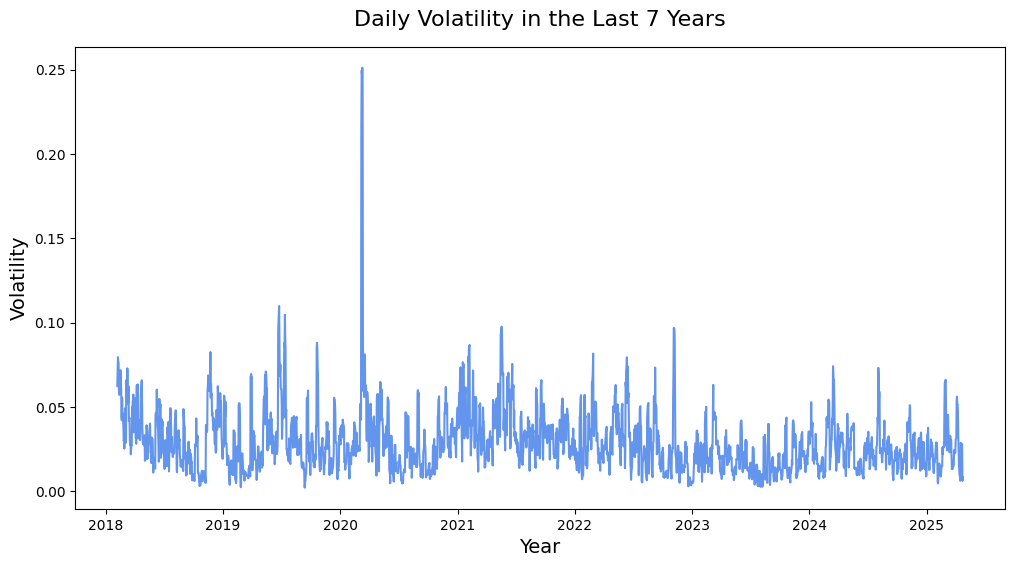

In [6]:
# Ensure 'date' column is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='volatility', data=df, color = "cornflowerblue")
# Format x-axis to show only years
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # Show tick per year

# Add axis labels and title
plt.xlabel("Year", fontsize=14)
plt.ylabel("Volatility", fontsize=14)
plt.title("Daily Volatility in the Last 7 Years", fontsize=16, pad=15)

# Save the figure
plt.savefig("../img/volatility.png", bbox_inches="tight", dpi=300)

# Show the plot
plt.show()

At first glance, it's clear that Bitcoin's volatility has experienced continuous ups and downs, highlighting how investor sentiment in crypto swings easily. Yet, almost all peaks and troughs remain within the 0 to 0.10 range, indicating a certain degree of volatility consistency over time.  
  
Particularly interesting is the sharp spike in volatility during the early months of 2020 — the onset of the COVID-19 pandemic and widespread lockdowns. As people were forced to stay home, their attention increasingly shifted toward digital assets like cryptocurrencies. Therefore, the volatility peak at the beginning of 2020 seems both notable and reasonable.  
  
Let’s zoom in on this period for a closer look.

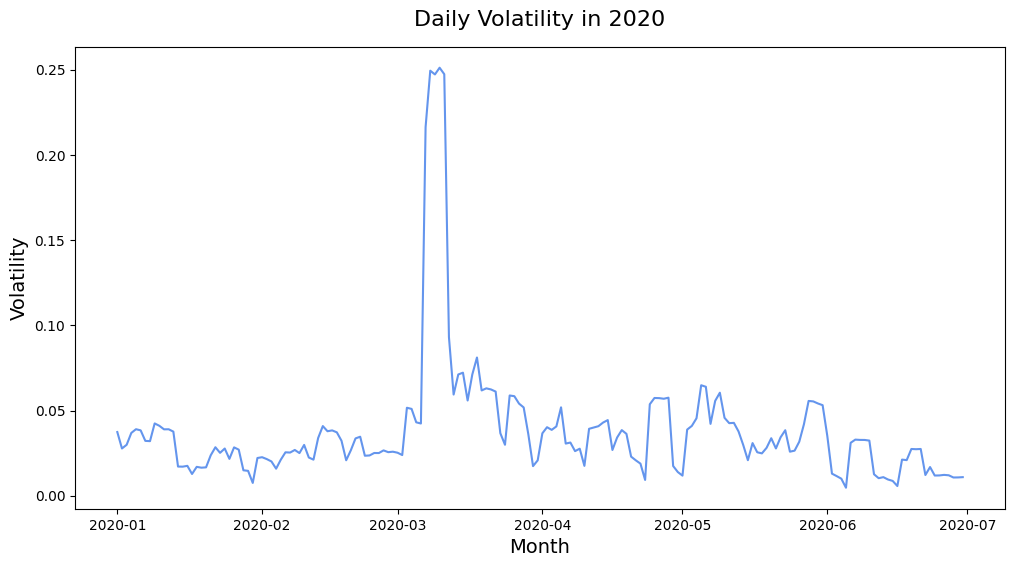

In [7]:
#define the start and ending date
start_date = "2020-01-01"
end_date = "2020-07-01"

# Filter data between two dates
filtered_df = df.loc[(df['date'] >= start_date)
                     & (df['date'] < end_date)]

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='volatility', data=filtered_df, color = "cornflowerblue")
# Add axis labels and title
plt.xlabel("Month", fontsize=14)
plt.ylabel("Volatility", fontsize=14)
plt.title("Daily Volatility in 2020", fontsize=16, pad=15)
# Show the plot
plt.show()

In [8]:
#check the max
df.iloc[df['volatility'].idxmax()]

date             2020-03-10 00:00:00
close                        7894.56
volume                  86783.443875
trend                             34
fg_index                        16.0
cluster                            5
log_return                 -0.004463
hl_spread                     420.99
momentum_3                    -992.1
vol_change             -30185.419393
rolling_std_5               0.043107
volatility                  0.251149
Name: 763, dtype: object

Zooming in on 2020, it becomes evident that the volatility spike occurred primarily during the first days of March. This sharp increase was the result of a brief but intense period for crypto markets, driven by a combination of impactful global events:  
  
- Black Thursday: A global market crash triggered by the official declaration of COVID-19 as a pandemic. Panic spread across all asset classes, including crypto.
- Mass Liquidations: Bitcoin’s price dropped by over 40% in a single day due to cascading liquidations. This magnified the sell-off and drove volatility to extreme levels.
- Dash for Cash: As investors rushed to cover losses and increase liquidity, many sold off riskier assets like cryptocurrencies to hoard cash.
- Market Sentiment: Although crypto is decentralized, it remained tied to broader market sentiment, reacting to global uncertainty like traditional markets.  
  
These few days, while appearing as outliers, reflect real and significant market behavior. For this reason, they will not be discarded. On the contrary, keeping them will enhance the model’s ability to recognize and learn from extreme events — an essential capability in volatility forecasting.


Turning to Volatility distribution, let's show it.

Text(0.5, 1.0, 'Volatility Distribution')

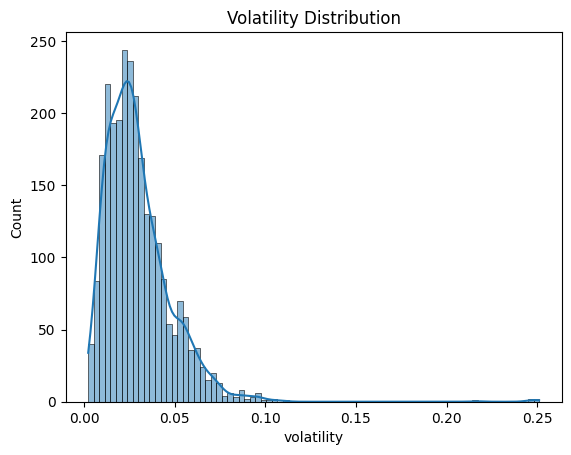

In [16]:
#show volatility distribution 
sns.histplot(df['volatility'], kde=True )
plt.title("Volatility Distribution")


The plot shows a right-skewed distribution of volatility values, with most observations concentrated between 0.01 and 0.05. The distribution peaks around 0.02–0.03, indicating that low volatility is most common in the dataset. A long tail extends to the right, showing a few instances of much higher volatility. This pattern suggests that while stable conditions dominate, occasional spikes in volatility occur.

### Target Variable & regressors relations

Shifting focus, it is a good idea to examine pairwise relations between Volatility and the regressors.

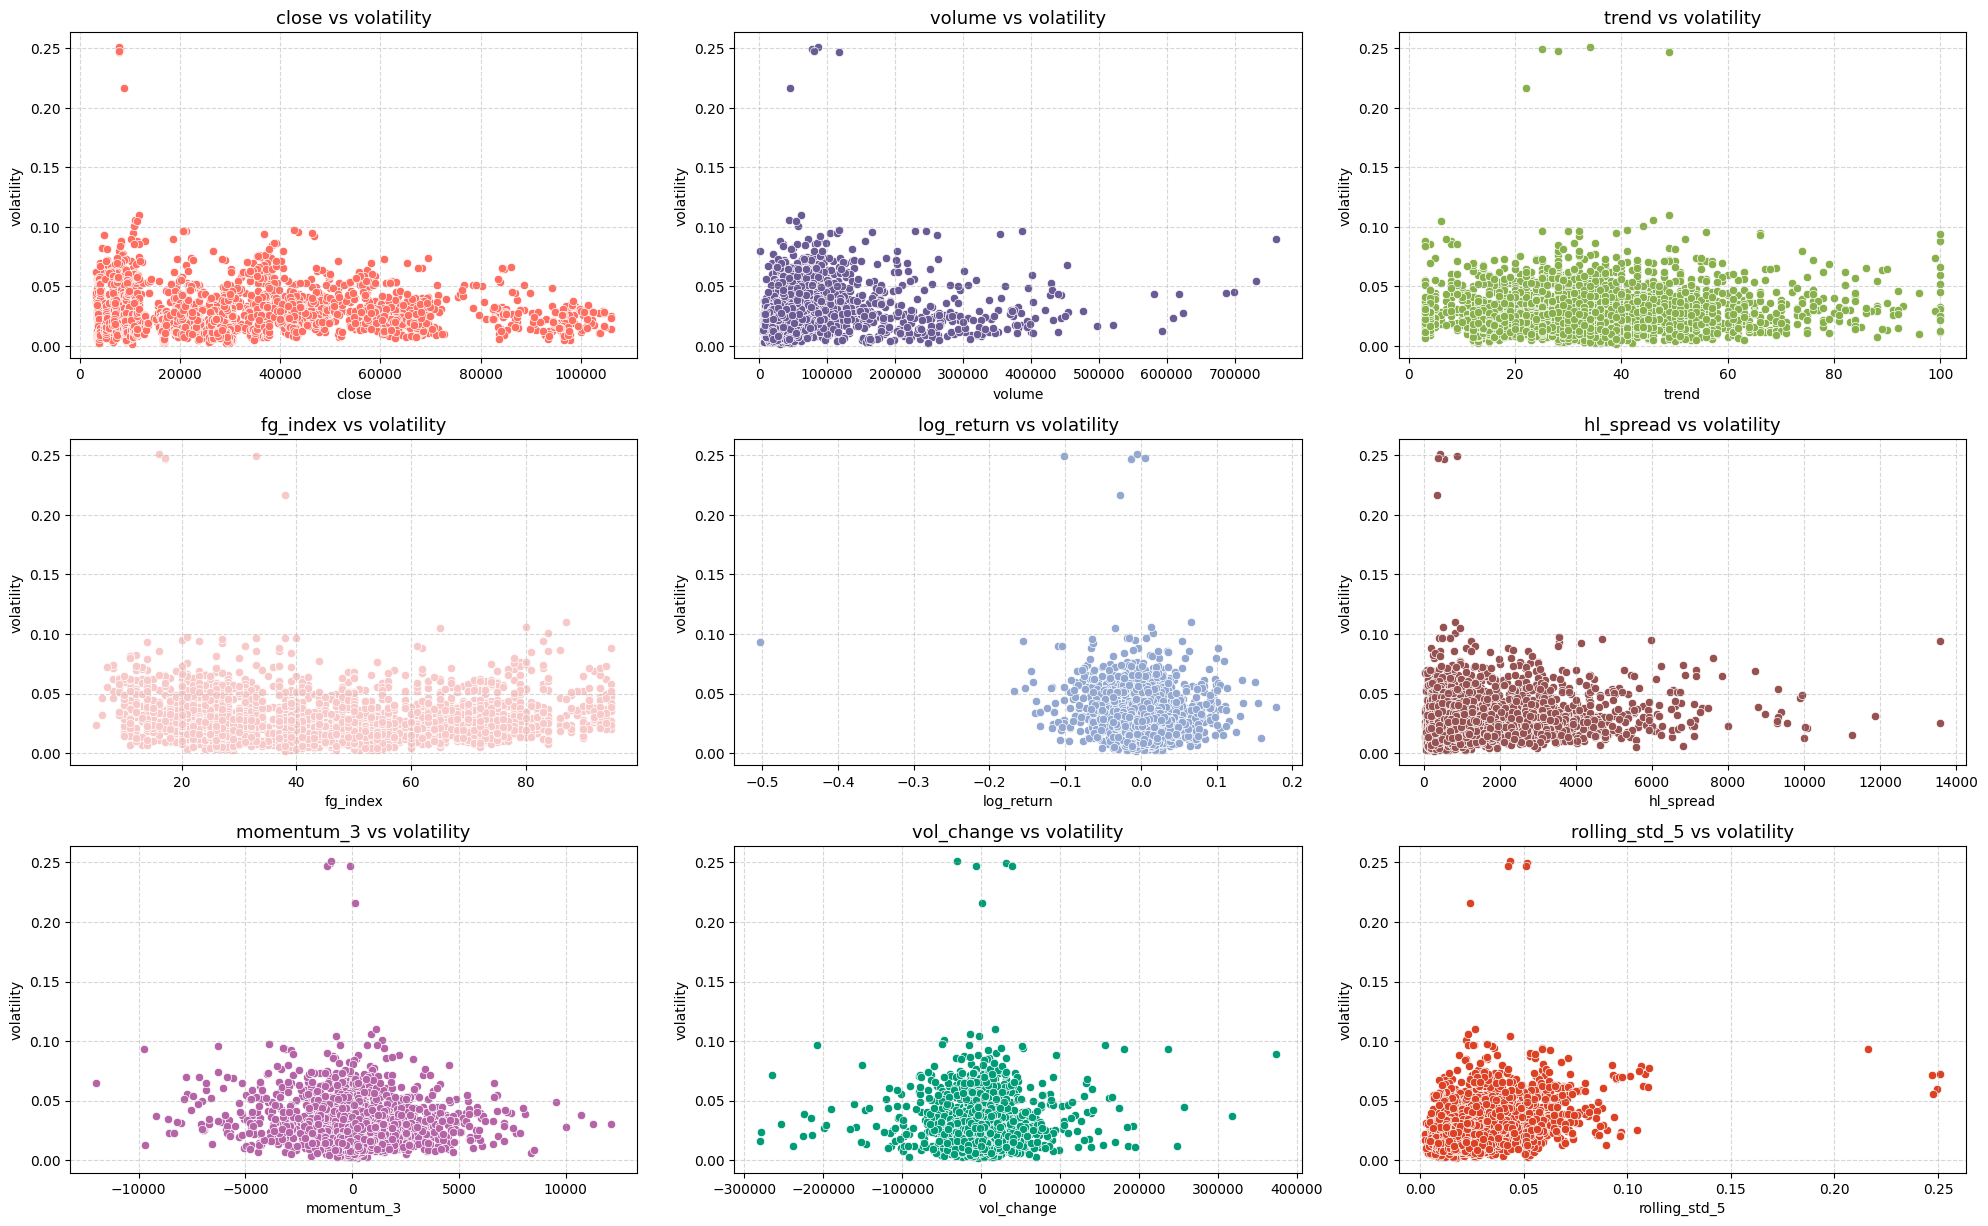

<Figure size 640x480 with 0 Axes>

In [10]:
# Assuming 'variables' is your list of 10 features (excluding 'date')
variables = df.columns.tolist()
variables.remove('date')
variables.remove('volatility')
variables.remove('cluster')

#define colors
colors = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1',
          '#955251', '#B565A7', '#009B77', '#DD4124']

# Set up a 4x3 grid
fig, axes = plt.subplots(4, 3, figsize=(20, 16))
#fig.suptitle("Scatterplots: Features vs hl_spread", fontsize=20, y=0.93)

# Flatten axes for easy iteration
axes = axes.flatten()

# Loop through variables
for i, var in enumerate(variables):
    sns.scatterplot(data=df, x=var, y='volatility', ax=axes[i], color=colors[i % len(colors)])
    axes[i].set_title(f"{var} vs volatility", fontsize=13)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("volatility")
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Remove any unused subplots (in your case, 2)
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#save it
plt.savefig("../img/scatterPlots.png", bbox_inches="tight", dpi=300)



At first glance, close, trend, and fg_index do not exhibit any clear relationship with volatility. The scatter points appear to be randomly dispersed around a flat line, likely near the mean volatility level, suggesting no evident pattern or directional association.  
    
Features like volume, hl_spread, and rolling_std_5 appear concentrated in the lower-right region of their respective plots. Among them, rolling_std_5 is the only variable that shows a modest positive relationship with volatility — as the 5-day rolling standard deviation increases, volatility also tends to rise, albeit weakly.  
  
Lastly, momentum_3 and vol_change form tight clouds centered around their means, with no discernible trend relative to volatility. This clustering indicates both that these variables are relatively stable and that they lack explanatory power for volatility fluctuations in this context.  
  
In summary, most features show little to no clear relationship with volatility, with rolling_std_5 being the only one hinting at a potential (though weak) positive correlation.

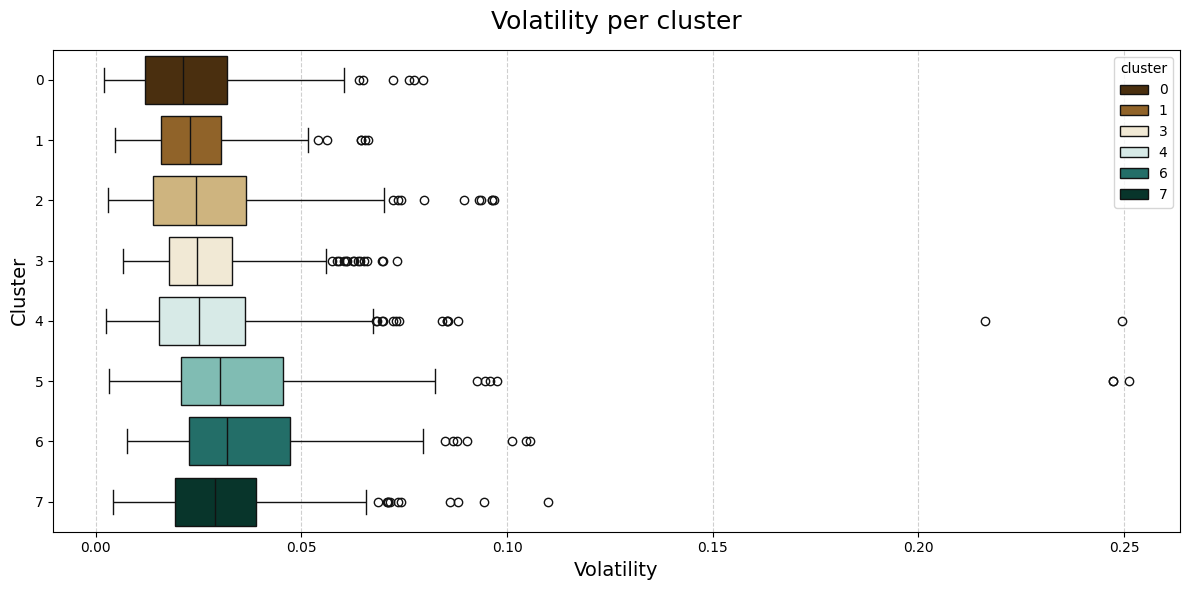

In [20]:
#boxplots for cluster
plt.figure(figsize=(12, 6))
# Create the boxplot
sns.boxplot(data=df, x='volatility', y='cluster', orient='h', hue = "cluster", palette='BrBG')
# Title and labels
plt.title("Volatility per cluster", fontsize=18, pad=15)
plt.xlabel("Volatility", fontsize=14)
plt.ylabel("Cluster", fontsize=14)
# Improve layout#
plt.grid(axis="x", linestyle="--", alpha=0.6)  # Add a light grid for readability
plt.tight_layout()
#save it
plt.savefig("../img/ClusterVolatility.png", bbox_inches="tight", dpi=300)
# Show the plot
plt.show()

Regarding cluster, clusters 2, 5, 6, and 7 show slightly elevated volatility levels, with clusters 4 and 5 containing most of the extreme outliers. However, the clusters do not reveal a strong or consistent separation in volatility, indicating that the grouping has limited predictive power for this target.  

### Regressors & target variable correlation

To conclude, data leak must be considered. Data leak could biases any predictive model's results. As a consequence, it must be throughly considered and, if necessary, tackled.
   
To prevent data leak, the first step is to ensure that none of the regressor is highly correlated with the target variable.
  
Note that, as the dataset is already enginereed, there should not be concerns about correlation.

In [12]:
df2 = df.drop(columns = ['date'])
#compute the entire correlation matrix
volcorr = df2.corr()
#filter just for the column left
volcorr = volcorr["volatility"].drop("volatility")
#print it
print("Correlation between Left and various regressors:")
volcorr

Correlation between Left and various regressors:


close           -0.067016
volume           0.080943
trend            0.058599
fg_index        -0.053917
cluster          0.181138
log_return      -0.075056
hl_spread        0.111571
momentum_3      -0.078222
vol_change       0.015993
rolling_std_5    0.317372
Name: volatility, dtype: float64

Shown in a heatmap.

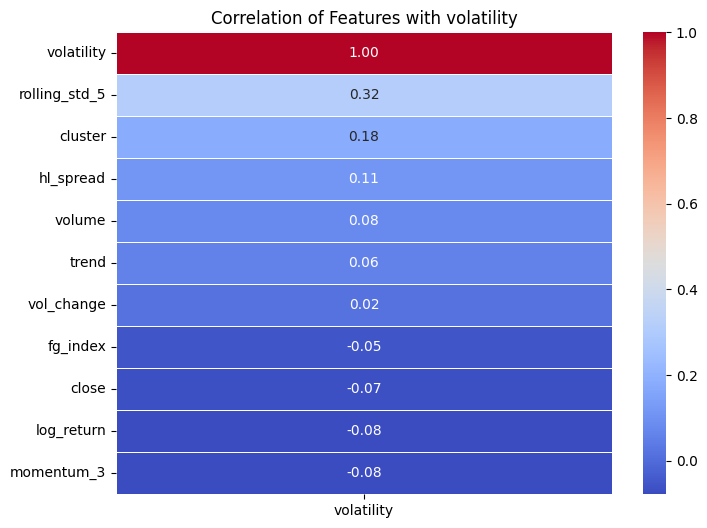

In [13]:
df2 = df.drop(columns = ['date'])
plot_correlation_with_target(df2, "volatility")

As observed from the scatterplots and confirmed by correlation values, the most correlated features with the target variable volatility are rolling_std_5 (≈ 0.32) and cluster (≈ 0.18).   
While these are the strongest among the set, their correlation still falls within the weak-to-moderate range, indicating no immediate risk of multicollinearity or data leakage. Notably, no variable shows an excessively high correlation (e.g., above 0.8), which points to potential leakage or target leakage.  
  
This suggests that while some predictors may offer valuable signals, none are simply echoing the target, a positive sign for model generalization.